## Fama-French Factor model - It answers what the asset price should be
1. Statistical Analysis:
- Runs multiple linear regression
- Calculates standard errors and t-statistics
- Computes p-values for statistical significance
- Provides R-squared for model fit

2. Factor Interpretations:
- Market Beta (β): Measures systematic risk
- SMB (Small Minus Big): Captures size premium
- HML (High Minus Low): Captures value premium
- Alpha (α): Measures excess return

3. Reporting Features:
- Generates detailed analysis reports
- Provides interpretation of coefficients
- Includes statistical significance measures

## FAMA FRENCH INTERPRETATION

In [1]:
def generate_report(results, ticker):
    """
    Generate a formatted report of the analysis results
    """
    report = f"""
        Fama-French Three Factor Model Analysis for {ticker}
        ================================================
        Interpretation:
        -------------
        -     α: {results['alpha']:.4f}. {'Positive' if results['alpha'] >= 0 else 'Negative'}. {'Outperforming' if results['alpha'] >= 0 else 'Underperforming'} the market.
        - β-MKT: {results['beta_mkt']:.4f}. {'Aggressive' if results['beta_mkt'] > 1 else 'Defensive'}. {'High' if results['beta_mkt'] > 1 else 'Low'} sensitivity to market swings.
        - β-SMB: {results['beta_smb']:.4f}. {'Positive' if results['beta_smb'] > 0 else 'Negative'}. The asset behaves like {'Small' if results['beta_smb'] > 0 else 'Large'} Caps.
        - β-HML: {results['beta_hml']:.4f}. {'Positive' if results['beta_hml'] > 0 else 'Negative'}. The asset behaves like {'Value' if results['beta_hml'] > 0 else 'Growth'} stocks.
        """
    return report

In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

### LOAD 3 FACTOR FAMA FRENCH

In [3]:
## Source Fama French Factors https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html
fff = pd.read_csv("../../../data/F-F_Research_Data_Factors_daily.csv",skiprows=4,skipfooter=2,engine="python", index_col=0)
# fff.index = pd.to_datetime(fff.index, format="%Y%m%d").date
fff.index = fff.index.astype("int32")
fff = fff/100

In [4]:
fff.tail()

,Mkt-RF,SMB,HML,RF
20251121,0.0103,0.0166,0.0074,0.0002
20251124,0.0161,0.0030,-0.0096,0.0002
20251125,0.0104,0.0165,0.0004,0.0002
20251126,0.0069,-0.0006,-0.0007,0.0002
20251128,0.0054,-0.0042,0.0036,0.0002


In [5]:
start_date = 20241001
end_date   = 20250930

### TSLA

In [6]:
ticker = "TSLA"
asset = pd.read_csv(f"../../../data/{ticker}.Daily.csv")
asset.set_index("timestamp", inplace=True)
# asset.index = pd.to_datetime(asset.index).date
asset.index = asset.index.str.replace("-","").astype("int32")
asset['returns'] = asset.close.pct_change()

### MERGE DATA

In [9]:
merged_data = fff.merge(asset[['returns']], left_index=True, right_index=True, how="inner")
# merged_data.index = pd.to_datetime(merged_data.index)

In [10]:
merged_data.tail()

,Mkt-RF,SMB,HML,RF,returns
20251121,0.0103,0.0166,0.0074,0.0002,-0.010475
20251124,0.0161,0.0030,-0.0096,0.0002,0.068245
20251125,0.0104,0.0165,0.0004,0.0002,0.003878
20251126,0.0069,-0.0006,-0.0007,0.0002,0.017120
20251128,0.0054,-0.0042,0.0036,0.0002,0.008416


### FIT THE MODEL

In [11]:
train, test  = merged_data.loc[start_date:end_date], merged_data[ merged_data.index > end_date]
train = train.dropna()
X = train[['Mkt-RF', 'SMB', 'HML']]
# y = train['returns'] - train['RF']
y = train['returns'] - train['RF']
X = sm.add_constant(X)
ff_model = sm.OLS(y, X).fit() #Fit the model
#Simple out of sample
oot_returns = ff_model.predict(sm.add_constant(test[['Mkt-RF', 'SMB', 'HML']])) #out of time prediction. NOT Rolling/Dynamic Learning

ff_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     58.94
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           9.56e-29
Time:                        23:35:24   Log-Likelihood:                 490.38
No. Observations:                 250   AIC:                            -972.8
Df Residuals:                     246   BIC:                            -958.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.002      0.770      0.442      -0.003       0.006
Mkt-RF         2.2676      0.202     11.232      0.000       1.870       2.665
SMB            0.3086      0.346      0.892      0.373      -0.373       0.990
HML           -0.1606      0.301     -0.534      0.594      -0.753       0.432
==============================================================================
Omnibus:                       58.284   Durbin-Watson:                   1.724
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              399.866
Skew:                           0.693   Prob(JB):                     1.48e-87
Kurtosis:                       9.039   Cond. No.                         167.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Fama-French Three Factor Model Analysis

In [12]:
parameters = {
            'alpha': ff_model.params["const"],
            'beta_mkt': ff_model.params["Mkt-RF"],
            'beta_smb': ff_model.params["SMB"],
            'beta_hml': ff_model.params["HML"]}
print(generate_report(parameters, ticker))


        Fama-French Three Factor Model Analysis for TSLA
        Interpretation:
        -------------
        -     α: 0.0017. Positive. Outperforming the market.
        - β-MKT: 2.2676. Aggressive. High sensitivity to market swings.
        - β-SMB: 0.3086. Positive. The asset behaves like Small Caps.
        - β-HML: -0.1606. Negative. The asset behaves like Growth stocks.
        


### Structure data for plotting

In [14]:
rfr = merged_data['RF']
# rfr.index = merged_data['index']
rfr.index.name = ""

model_output = pd.concat([ff_model.fittedvalues, oot_returns],axis=1)
model_output.columns = ['In Sample','Simple OOS']
model_output = model_output.add(rfr.loc[start_date:], axis=0) #Add back the risk free rate
plot_output = pd.merge(asset[['close','returns']], model_output, how="inner", left_index=True, right_index=True)

plot_output[f'In Sample {ticker}'] = plot_output['close'].shift(1) * (1 + plot_output['In Sample'])
plot_output[f'Simple OOS {ticker}'] = plot_output['close'].shift(1) * (1 + plot_output['Simple OOS'])
plot_output.index = pd.to_datetime(plot_output.index, format="%Y%m%d").date
# temp.plot()

### In sample and out of sample (gray) comparison. 

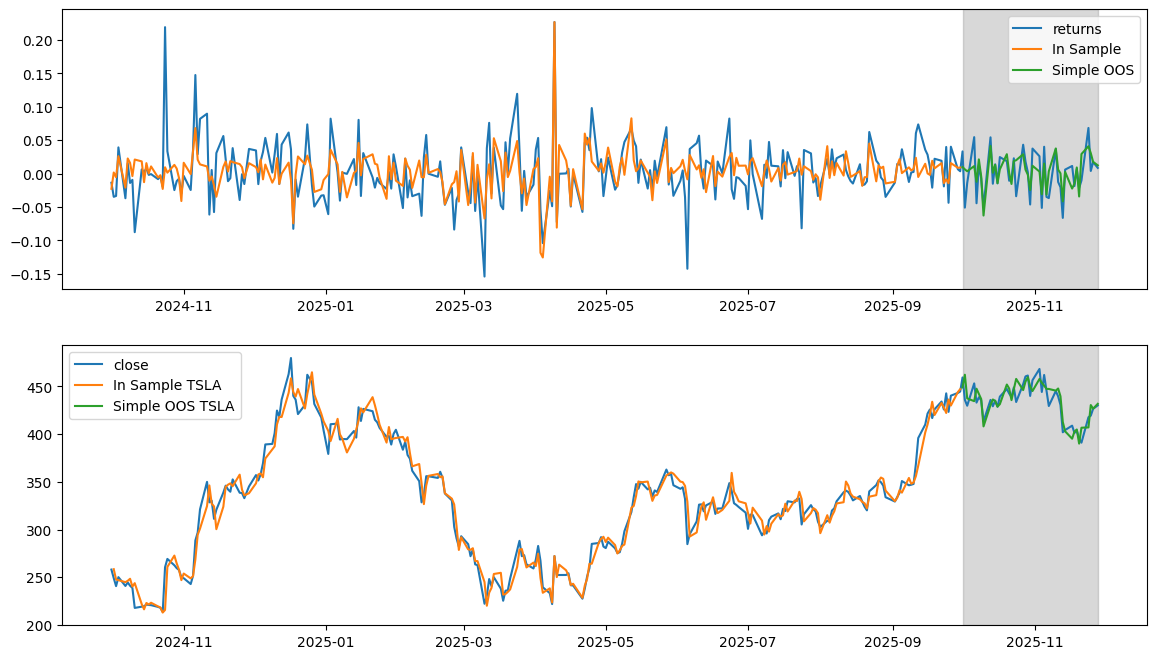

In [16]:
plot_start_date = pd.to_datetime(start_date,format="%Y%m%d").date()
oo_start_date = pd.to_datetime(oot_returns.index[0],format="%Y%m%d").date()
oo_end_date = pd.to_datetime(oot_returns.index[oot_returns.shape[0]-1],format="%Y%m%d").date()
fig, axes = plt.subplots(2, 1, figsize=(14,8))
#Returns
ax1 = plot_output.loc[plot_start_date:,["returns", "In Sample" ,"Simple OOS"]].plot(ax=axes[0])
ax1.axvspan(oo_start_date, oo_end_date, color='grey', alpha=0.3)

ax2 = plot_output.loc[plot_start_date:,['close', f'In Sample {ticker}', f'Simple OOS {ticker}']].plot(ax=axes[1])
ax2.axvspan(oo_start_date, oo_end_date, color='grey', alpha=0.3)

### MSTR


        Fama-French Three Factor Model Analysis for MSTR
        Interpretation:
        -------------
        -     α: 0.0034. Positive. Outperforming the market.
        - β-MKT: 1.7984. Aggressive. High sensitivity to market swings.
        - β-SMB: 1.7281. Positive. The asset behaves like Small Caps.
        - β-HML: -0.6077. Negative. The asset behaves like Growth stocks.
        


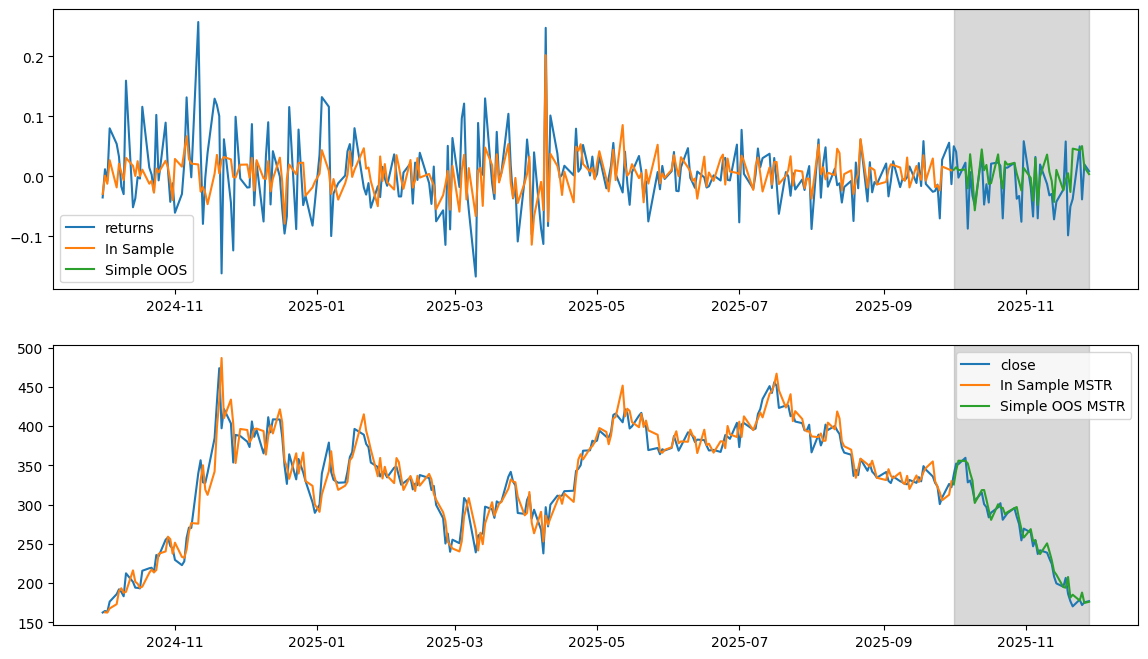

In [17]:
ticker = "MSTR"
asset = pd.read_csv(f"../../../data/{ticker}.Daily.csv")
asset.set_index("timestamp", inplace=True)
# asset.index = pd.to_datetime(asset.index).date
asset.index = asset.index.str.replace("-","").astype("int32")
asset['returns'] = asset.close.pct_change()

merged_data = fff.merge(asset[['returns']], left_index=True, right_index=True, how="inner")
# merged_data.index = pd.to_datetime(merged_data.index)
### FIT THE MODEL
train, test  = merged_data.loc[start_date:end_date], merged_data[ merged_data.index > end_date]
train = train.dropna()
X = train[['Mkt-RF', 'SMB', 'HML']]
# y = train['returns'] - train['RF']
y = train['returns'] - train['RF']
X = sm.add_constant(X)
ff_model = sm.OLS(y, X).fit() #Fit the model
#Simple out of sample
oot_returns = ff_model.predict(sm.add_constant(test[['Mkt-RF', 'SMB', 'HML']])) #out of time prediction. NOT Rolling/Dynamic Learning

parameters = {
            'alpha': ff_model.params["const"],
            'beta_mkt': ff_model.params["Mkt-RF"],
            'beta_smb': ff_model.params["SMB"],
            'beta_hml': ff_model.params["HML"]}
print(generate_report(parameters, ticker))

### Rolling out of sample


### Structure data for plotting
rfr = merged_data['RF']
# rfr.index = merged_data['index']
rfr.index.name = ""

model_output = pd.concat([ff_model.fittedvalues, oot_returns],axis=1)
model_output.columns = ['In Sample','Simple OOS']
model_output = model_output.add(rfr.loc[start_date:], axis=0) #Add back the risk free rate
plot_output = pd.merge(asset[['close','returns']], model_output, how="inner", left_index=True, right_index=True)

plot_output[f'In Sample {ticker}'] = plot_output['close'].shift(1) * (1 + plot_output['In Sample'])
plot_output[f'Simple OOS {ticker}'] = plot_output['close'].shift(1) * (1 + plot_output['Simple OOS'])
plot_output.index = pd.to_datetime(plot_output.index, format="%Y%m%d").date
# temp.plot()
### In sample and out of sample (gray) comparison. 
plot_start_date = pd.to_datetime(start_date,format="%Y%m%d").date()
oo_start_date = pd.to_datetime(oot_returns.index[0],format="%Y%m%d").date()
oo_end_date = pd.to_datetime(oot_returns.index[oot_returns.shape[0]-1],format="%Y%m%d").date()
fig, axes = plt.subplots(2, 1, figsize=(14,8))
#Returns
ax1 = plot_output.loc[plot_start_date:,["returns", "In Sample" ,"Simple OOS"]].plot(ax=axes[0])
ax1.axvspan(oo_start_date, oo_end_date, color='grey', alpha=0.3)

ax2 = plot_output.loc[plot_start_date:,['close', f'In Sample {ticker}', f'Simple OOS {ticker}']].plot(ax=axes[1])
ax2.axvspan(oo_start_date, oo_end_date, color='grey', alpha=0.3)

## Coca Cola


        Fama-French Three Factor Model Analysis for KO
        Interpretation:
        -------------
        -     α: -0.0007. Negative. Underperforming the market.
        - β-MKT: 0.2206. Defensive. Low sensitivity to market swings.
        - β-SMB: -0.4573. Negative. The asset behaves like Large Caps.
        - β-HML: 0.3253. Positive. The asset behaves like Value stocks.
        


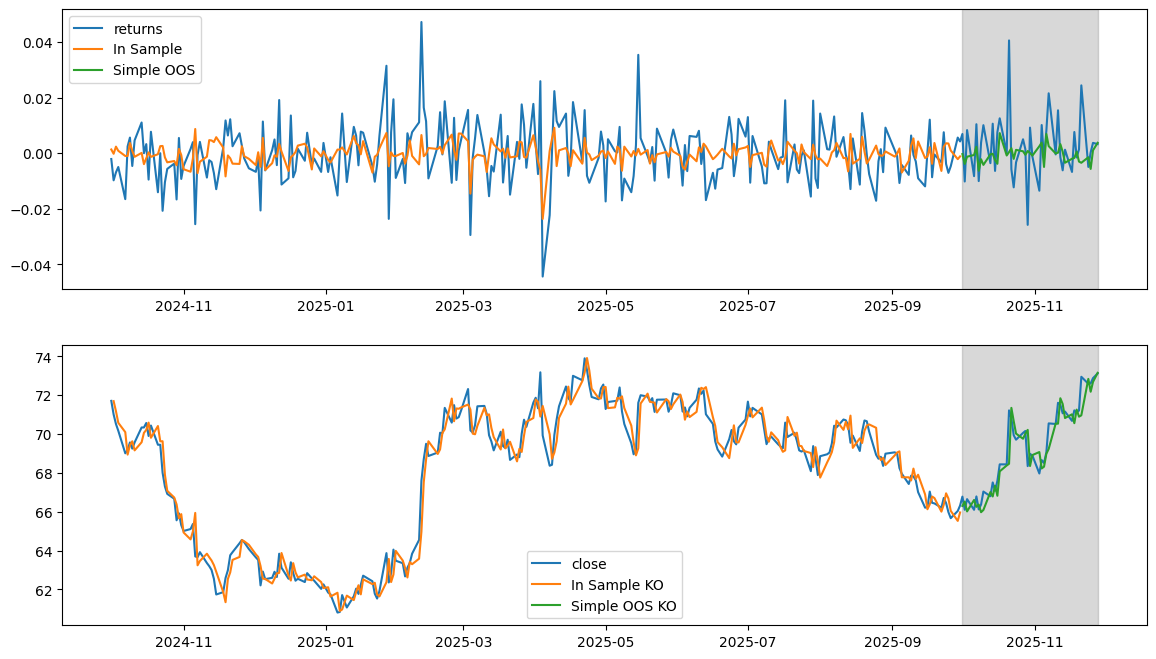

In [20]:
ticker = "KO"
asset = pd.read_csv(f"../../../data/{ticker}.Daily.csv")
asset.set_index("timestamp", inplace=True)
# asset.index = pd.to_datetime(asset.index).date
asset.index = asset.index.str.replace("-","").astype("int32")
asset['returns'] = asset.close.pct_change()

merged_data = fff.merge(asset[['returns']], left_index=True, right_index=True, how="inner")
# merged_data.index = pd.to_datetime(merged_data.index)
### FIT THE MODEL
train, test  = merged_data.loc[start_date:end_date], merged_data[ merged_data.index > end_date]
train = train.dropna()
X = train[['Mkt-RF', 'SMB', 'HML']]
# y = train['returns'] - train['RF']
y = train['returns'] - train['RF']
X = sm.add_constant(X)
ff_model = sm.OLS(y, X).fit() #Fit the model
#Simple out of sample
oot_returns = ff_model.predict(sm.add_constant(test[['Mkt-RF', 'SMB', 'HML']])) #out of time prediction. NOT Rolling/Dynamic Learning

parameters = {
            'alpha': ff_model.params["const"],
            'beta_mkt': ff_model.params["Mkt-RF"],
            'beta_smb': ff_model.params["SMB"],
            'beta_hml': ff_model.params["HML"]}
print(generate_report(parameters, ticker))


### Structure data for plotting
rfr = merged_data['RF']
# rfr.index = merged_data['index']
rfr.index.name = ""

model_output = pd.concat([ff_model.fittedvalues, oot_returns],axis=1)
model_output.columns = ['In Sample','Simple OOS']
model_output = model_output.add(rfr.loc[start_date:], axis=0) #Add back the risk free rate
plot_output = pd.merge(asset[['close','returns']], model_output, how="inner", left_index=True, right_index=True)

plot_output[f'In Sample {ticker}'] = plot_output['close'].shift(1) * (1 + plot_output['In Sample'])
plot_output[f'Simple OOS {ticker}'] = plot_output['close'].shift(1) * (1 + plot_output['Simple OOS'])
plot_output.index = pd.to_datetime(plot_output.index, format="%Y%m%d").date
# temp.plot()
### In sample and out of sample (gray) comparison. 
plot_start_date = pd.to_datetime(start_date,format="%Y%m%d").date()
oo_start_date = pd.to_datetime(oot_returns.index[0],format="%Y%m%d").date()
oo_end_date = pd.to_datetime(oot_returns.index[oot_returns.shape[0]-1],format="%Y%m%d").date()
fig, axes = plt.subplots(2, 1, figsize=(14,8))
#Returns
ax1 = plot_output.loc[plot_start_date:,["returns", "In Sample" ,"Simple OOS"]].plot(ax=axes[0])
ax1.axvspan(oo_start_date, oo_end_date, color='grey', alpha=0.3)

ax2 = plot_output.loc[plot_start_date:,['close', f'In Sample {ticker}', f'Simple OOS {ticker}']].plot(ax=axes[1])
ax2.axvspan(oo_start_date, oo_end_date, color='grey', alpha=0.3)

## What can be done next to improve on this?
- Experiment with the idea what if Fama French factors were available daily as opposed to being published once a month
- This way the asset price can be more aware of the market condition
- Rolling regression